## Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split and cross-validation
from sklearn.model_selection import train_test_split, cross_val_score

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df=pd.read_csv('novagen_dataset.csv')

In [3]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [4]:
df.columns

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='object')

In [5]:
df.isnull().sum()

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

<Axes: xlabel='BMI', ylabel='Count'>

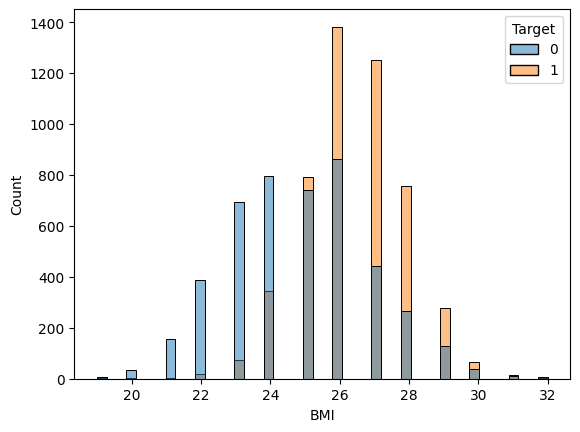

In [7]:
sns.histplot(
    data=df,
    x='BMI',
    hue='Target'
    
)

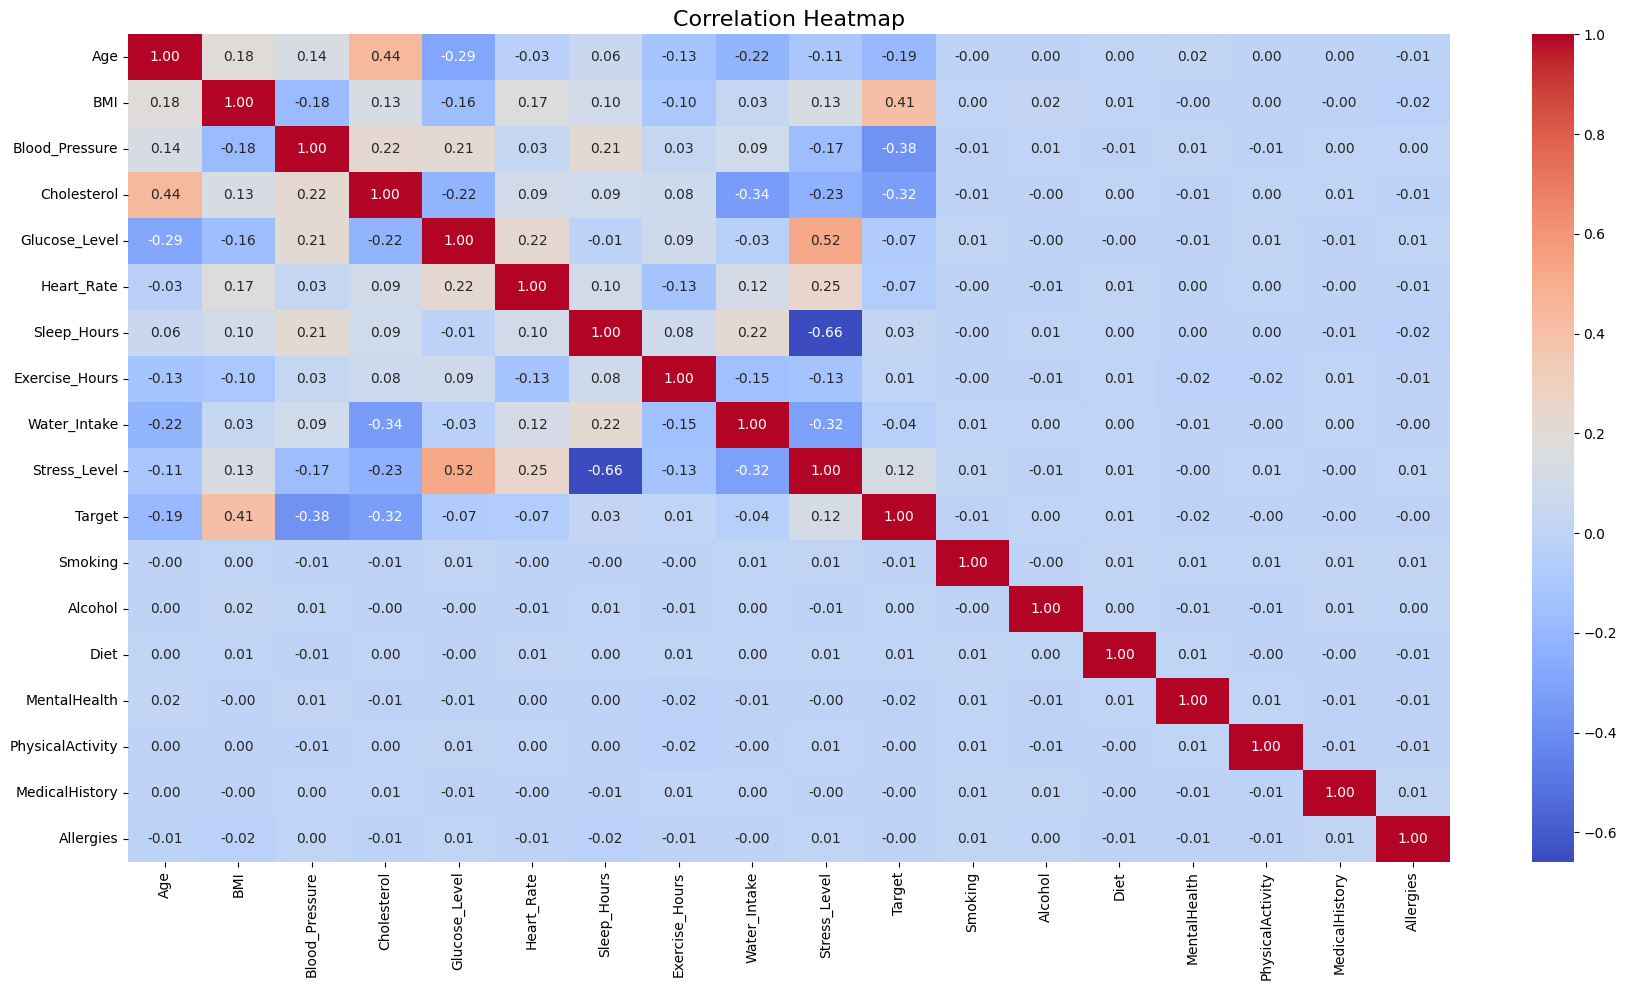

In [8]:
num_cols = df.select_dtypes(include='number')
matrix = num_cols.corr()

plt.figure(figsize=(18, 10))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

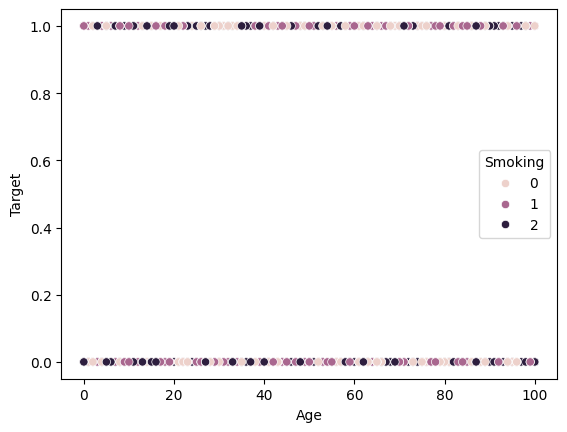

In [16]:
sns.scatterplot(
    data=df,
    x='Age',
    y='Target',
    hue='Smoking'
)
plt.show()

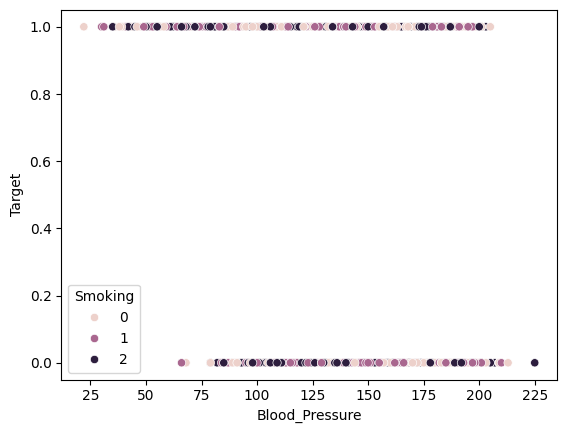

In [42]:
sns.scatterplot(
    data=df,
    x='Blood_Pressure',
    y='Target',
    hue='Smoking'
)
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

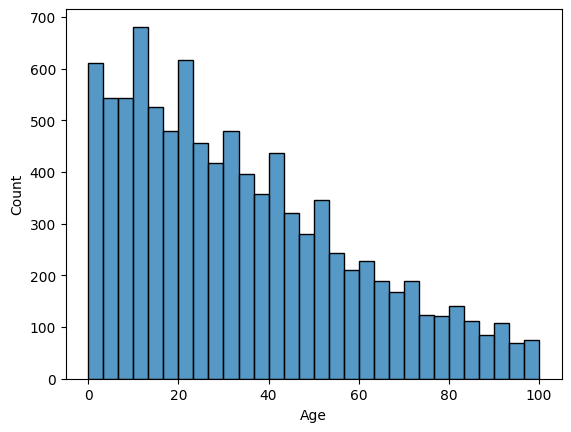

In [22]:
sns.histplot(
    data=df,
    x='Age'
)

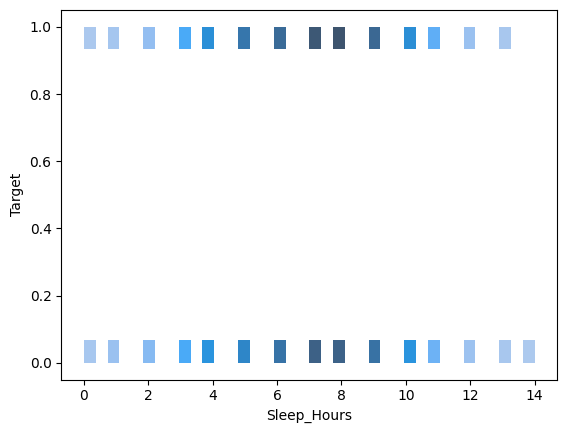

In [25]:
sns.histplot(
    data=df,
    x='Sleep_Hours',
    y='Target'
)
plt.show()

In [12]:
df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,0.521416,0.990470,0.995183,1.005864,0.998429,1.003351,1.004713,0.989318
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,0.499567,0.815521,0.816653,0.815877,0.821844,0.808800,0.813506,0.815699
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [24]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [26]:
df['Smoking'].unique()

array([2, 0, 1])

In [27]:
df['Sleep_Hours'].unique()

array([ 4.,  2., 10.,  7.,  6.,  9., 11.,  5.,  8.,  3.,  1., 12., 13.,
        0., 14.])

<Axes: xlabel='Age'>

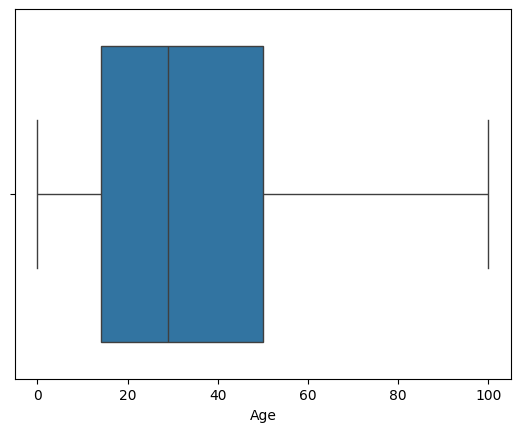

In [28]:
sns.boxplot(
    data=df,
    x='Age'
)

<Axes: xlabel='Sleep_Hours'>

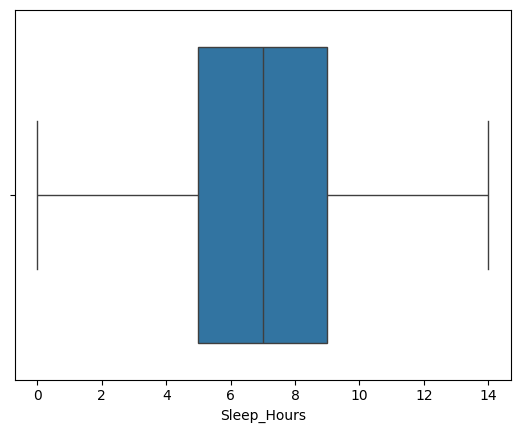

In [29]:
sns.boxplot(
    data=df,
    x='Sleep_Hours'
)

In [45]:
X=df.drop('Target',axis=1)
y=df['Target']

In [46]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Random Forest

In [54]:
RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
y_preds=model1.predict(X_test)

In [57]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     confusion_matrix,
#     classification_report
# )

print("Random Forest")

# print(f"Training Accuracy: {accuracy_score(y_train, model.predict(X_train)) * 100:.2f}%")
print(f"Test Accuracy    : {accuracy_score(y_test, y_preds) * 100:.2f}%")
print(f"Precision        : {precision_score(y_test, y_preds) * 100:.2f}%")
print(f"Recall           : {recall_score(y_test, y_preds) * 100:.2f}%")
print(f"F1 Score         : {f1_score(y_test, y_preds) * 100:.2f}%")

Random Forest
Test Accuracy    : 94.19%
Precision        : 95.18%
Recall           : 93.76%
F1 Score         : 94.46%


# Decision Tree Start

In [58]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_preds = dt.predict(X_test)

In [59]:
print("Decision Tree")
print(f"Training Accuracy: {accuracy_score(y_train, dt.predict(X_train)) * 100:.2f}%")
print(f"Test Accuracy    : {accuracy_score(y_test, y_preds) * 100:.2f}%")
print(f"Precision        : {precision_score(y_test, y_preds) * 100:.2f}%")
print(f"Recall           : {recall_score(y_test, y_preds) * 100:.2f}%")
print(f"F1 Score         : {f1_score(y_test, y_preds) * 100:.2f}%")

Decision Tree
Training Accuracy: 93.18%
Test Accuracy    : 90.52%
Precision        : 92.25%
Recall           : 89.60%
F1 Score         : 90.91%


# KNN Start

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train_scaled, y_train)

y_preds = knn.predict(X_test_scaled)

print("KNN")
print(f"Training Accuracy: {accuracy_score(y_train, knn.predict(X_train_scaled)) * 100:.2f}%")
print(f"Test Accuracy    : {accuracy_score(y_test, y_preds) * 100:.2f}%")
print(f"Precision        : {precision_score(y_test, y_preds) * 100:.2f}%")
print(f"Recall           : {recall_score(y_test, y_preds) * 100:.2f}%")
print(f"F1 Score         : {f1_score(y_test, y_preds) * 100:.2f}%")

KNN
Training Accuracy: 92.20%
Test Accuracy    : 88.06%
Precision        : 89.02%
Recall           : 88.32%
F1 Score         : 88.67%


# Logistic Regression Start

In [63]:
logistic = LogisticRegression(max_iter=1000)

logistic.fit(X_train_scaled, y_train)

y_preds = logistic.predict(X_test_scaled)

print("Logistic Regression")
print(f"Training Accuracy: {accuracy_score(y_train, logistic.predict(X_train_scaled)) * 100:.2f}%")
print(f"Test Accuracy    : {accuracy_score(y_test, y_preds) * 100:.2f}%")
print(f"Precision        : {precision_score(y_test, y_preds) * 100:.2f}%")
print(f"Recall           : {recall_score(y_test, y_preds) * 100:.2f}%")
print(f"F1 Score         : {f1_score(y_test, y_preds) * 100:.2f}%")

Logistic Regression
Training Accuracy: 81.52%
Test Accuracy    : 82.25%
Precision        : 82.86%
Recall           : 83.76%
F1 Score         : 83.31%


# Naive Bayes Start

In [64]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_preds = nb.predict(X_test_scaled)

print("Naive Bayes")
print(f"Training Accuracy: {accuracy_score(y_train, nb.predict(X_train_scaled)) * 100:.2f}%")
print(f"Test Accuracy    : {accuracy_score(y_test, y_preds) * 100:.2f}%")
print(f"Precision        : {precision_score(y_test, y_preds) * 100:.2f}%")
print(f"Recall           : {recall_score(y_test, y_preds) * 100:.2f}%")
print(f"F1 Score         : {f1_score(y_test, y_preds) * 100:.2f}%")

Naive Bayes
Training Accuracy: 81.15%
Test Accuracy    : 82.09%
Precision        : 84.50%
Recall           : 80.99%
F1 Score         : 82.71%


# Support Vector Machine (SVM) Start

In [65]:
svm = SVC(kernel="rbf", random_state=42)

svm.fit(X_train_scaled, y_train)

y_preds = svm.predict(X_test_scaled)

print("SVM")
print(f"Training Accuracy: {accuracy_score(y_train, svm.predict(X_train_scaled)) * 100:.2f}%")
print(f"Test Accuracy    : {accuracy_score(y_test, y_preds) * 100:.2f}%")
print(f"Precision        : {precision_score(y_test, y_preds) * 100:.2f}%")
print(f"Recall           : {recall_score(y_test, y_preds) * 100:.2f}%")
print(f"F1 Score         : {f1_score(y_test, y_preds) * 100:.2f}%")

SVM
Training Accuracy: 95.09%
Test Accuracy    : 93.35%
Precision        : 93.24%
Recall           : 94.26%
F1 Score         : 93.75%


In [67]:
import pandas as pd

results = {
    "🏆 Rank": [
        "🥇 1st",
        "🥈 2nd",
        "🥉 3rd",
        "4️⃣ 4th",
        "5️⃣ 5th",
        "6️⃣ 6th"
    ],
    
    "🤖 Model": [
        "🌲 Random Forest",
        "⚡ SVM",
        "🌳 Decision Tree",
        "📍 KNN",
        "📈 Logistic Regression",
        "🧮 Naive Bayes"
    ],
    
    "🎯 Training Accuracy": [
        100.00,
        95.09,
        93.18,
        92.20,
        81.52,
        81.15
    ],
    
    "🧪 Test Accuracy": [
        94.19,
        93.35,
        90.52,
        88.06,
        82.25,
        82.09
    ],
    
    "🎯 Precision": [
        95.18,
        93.24,
        92.25,
        89.02,
        82.86,
        84.50
    ],
    
    "🔍 Recall": [
        93.76,
        94.26,
        89.60,
        88.32,
        83.76,
        80.99
    ],
    
    "⚖️ F1 Score": [
        94.46,
        93.75,
        90.91,
        88.67,
        83.31,
        82.71
    ]
}

results_df = pd.DataFrame(results)

# Format percentages
percentage_columns = [
    "🎯 Training Accuracy",
    "🧪 Test Accuracy",
    "🎯 Precision",
    "🔍 Recall",
    "⚖️ F1 Score"
]

for col in percentage_columns:
    results_df[col] = results_df[col].apply(lambda x: f"{x:.2f}%")

# Display table
display(results_df.style
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid black"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("border", "2px solid black"),
                    ("font-weight", "bold")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("border", "1px solid black")
                ]
            }
        ])
)

,🏆 Rank,🤖 Model,🎯 Training Accuracy,🧪 Test Accuracy,🎯 Precision,🔍 Recall,⚖️ F1 Score
0,🥇 1st,🌲 Random Forest,100.00%,94.19%,95.18%,93.76%,94.46%
1,🥈 2nd,⚡ SVM,95.09%,93.35%,93.24%,94.26%,93.75%
2,🥉 3rd,🌳 Decision Tree,93.18%,90.52%,92.25%,89.60%,90.91%
3,4️⃣ 4th,📍 KNN,92.20%,88.06%,89.02%,88.32%,88.67%
4,5️⃣ 5th,📈 Logistic Regression,81.52%,82.25%,82.86%,83.76%,83.31%
5,6️⃣ 6th,🧮 Naive Bayes,81.15%,82.09%,84.50%,80.99%,82.71%
